In [79]:
import pandas as pd
import numpy as np

In [105]:
df=pd.read_csv(r'C:\Users\G Anirudh\VIT\ML\data sets\titanic.csv')
df.sample(3)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [82]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [83]:
df.isnull().mean()*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [84]:
# dealing with string type first
df.select_dtypes(include='object').nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

In [85]:
df.drop(columns=['Name','PassengerId','Cabin','Ticket'],inplace=True)
# dropping cabin as too much missing
# dropping name and passengerId as don't follow any pattern

In [86]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [87]:
df.isnull().mean()*100


Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Embarked     0.224467
dtype: float64

In [88]:
# have to deal with the  sex and the embarked both are onehotencoder

In [89]:
# STEP 4 

In [90]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import  ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [91]:
# one hot encode the strings
# imputing(replacing the value with mean/median)=>numerical
#

In [92]:
X=df.drop(columns=['Survived'])
Y=df['Survived']

In [93]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [94]:
numer_col=['Age','SibSp','Pclass','Fare','Parch']
cat_col=['Sex','Embarked']

In [95]:
num_pipeline=Pipeline([
    ('imputing_num',SimpleImputer(strategy='median'))
])

In [96]:
cat_pipeline=Pipeline([
    ('imputing_cat',SimpleImputer(strategy='most_frequent')),
    ('changing_to_num',OneHotEncoder(drop='first',handle_unknown='ignore'))
])

In [97]:
preprocessor=ColumnTransformer([
    ('cat',cat_pipeline,cat_col),
    ('num',num_pipeline,numer_col)
])

In [98]:
x_train_transformed=preprocessor.fit_transform(x_train)
x_test_transformed=preprocessor.transform(x_test)

In [99]:
x_train_transformed.shape

(712, 8)

In [100]:
x_test_transformed.shape

(179, 8)

In [101]:
# remove the columsn which we know wont help
#-> if the unique valeus are above 90%  as they act as id (like name)
#-> if the column has null vlaues greater than 50%
#-> if the no of unique strings in a categorical column is greater than 10
def classify_and_clean(df,target_col=None,id_threshold=0.9,missing_threshold=0.5,cardinality_threshold=10):
    if target_col:
        df=df.drop(columns=[target_col])
    nrows=len(df)
    drop_cols=[]
    numeric_cols=[]
    categorical_cols=[]
    for cols in df.columns:
        # condition 1: if the no of unique values are greater than 90% it must be some sort of id(name)
        if df[cols].nunique()/nrows>id_threshold:
            drop_cols.append(cols)
            continue
        # condition 2 : if the missing values are greater than 50% remove those columns
        if df[cols].isnull().sum()/nrows>missing_threshold:
            drop_cols.append(cols)
            continue
        # condition 3: if the no of values in a categorical col is greater than 10 remove.
        # else if its numerical add it to the numerical type
        if df[cols].dtype in ['int64','float64','int32','float32']:
            numeric_cols.append(cols)
            
        else:
            if df[cols].nunique()<=cardinality_threshold:
                categorical_cols.append(cols)
            else: 
                drop_cols.append(cols)
    return numeric_cols,categorical_cols,drop_cols
    


In [102]:
def build_auto_pipeline(numeric_cols,categorical_cols):
    #create two pipelines ,one for numeric and other for categorical
   
    num_pipeline=Pipeline([
        ('imputer',SimpleImputer(strategy='median')),
        ('scalar',StandardScaler())
    ])
    cat_pipeline=Pipeline([
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(drop='first',handle_unknown='ignore'))
    ])
    #ColumnTransformer is used to impute the missing values with median(for numeric) or with most frequent(cat)
    #then convert it to nuerical using oneHotEncoding and remove the relatnoal issue by dropping first columns
    preprocessor=ColumnTransformer([
        ('num_trans',num_pipeline,numeric_cols),
        ('cat_trans',cat_pipeline,categorical_cols)
    ])
    return preprocessor
    
    
    

In [103]:
# test
df_raw=pd.read_csv(r'C:\Users\G Anirudh\VIT\ML\data sets\titanic.csv')
pre=build_auto_pipeline(numeric_cols,categorical_cols)
x_raw=df_raw.drop(columns=drop_cols+['Survived'])
y_raw=df_raw['Survived']
x_train_r,x_test_r,y_train_r,y_test_r=train_test_split(x_raw,y_raw,test_size=0.2,random_state=42)
x_train_r_transformed=pre.fit_transform(x_train_r)
x_test_r_transformed=pre.transform(x_test_r)
print(x_train_r_transformed.shape)
print(x_test_r_transformed.shape)

(712, 8)
(179, 8)


In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model=LogisticRegression()
model.fit(x_train_r_transformed,y_train_r)
y_pred=model.predict(x_test_r_transformed)
accuracy_score(y_test,y_pred)

0.8100558659217877

In [106]:
def generate_eda_report(df_before,df_after,drop_cols,numeric_cols,categorical_cols):
    report={}
    report['shape_before']=df_before.shape
    report['shape_after']=df_after.shape if hasattr(df_after,'shape') else None
    report['missing_before']=df_before.isnull().sum().to_dict()
    report['dropped_columns']=drop_cols
    report['numeric_columns']=numeric_cols
    report['categorical_columns']=categorical_cols
    report['numeric_summary']=df_before[numeric_cols].describe().to_dict()

    for col in categorical_cols:
        report[f'{col}_value_counts']=df_before[col].value_counts().to_dict()
    return report


In [108]:
report = generate_eda_report(df_raw, x_train_r_transformed, drop_cols, numeric_cols, categorical_cols)

print("Shape before:", report['shape_before'])
print("Shape after:", report['shape_after'])
print("Missing values before:", report['missing_before'])
print("Dropped columns:", report['dropped_columns'])

Shape before: (891, 12)
Shape after: (712, 8)
Missing values before: {'PassengerId': 0, 'Survived': 0, 'Pclass': 0, 'Name': 0, 'Sex': 0, 'Age': 177, 'SibSp': 0, 'Parch': 0, 'Ticket': 0, 'Fare': 0, 'Cabin': 687, 'Embarked': 2}
Dropped columns: ['PassengerId', 'Name', 'Ticket', 'Cabin']


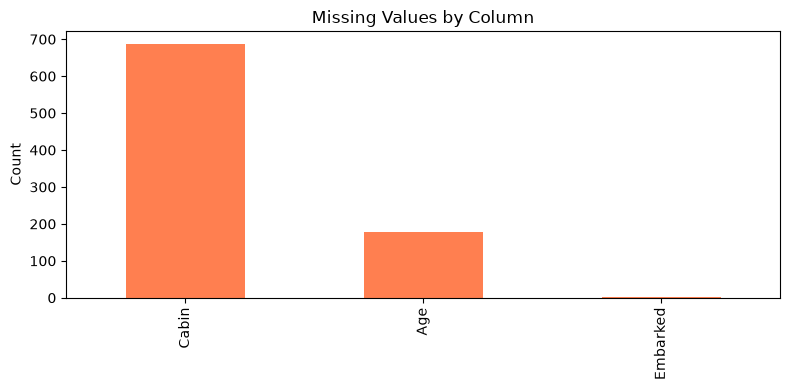

In [109]:
import matplotlib.pyplot as plt

def plot_missing_values(missing_dict):
    missing_series = pd.Series(missing_dict)
    missing_series = missing_series[missing_series > 0].sort_values(ascending=False)
    
    plt.figure(figsize=(8,4))
    missing_series.plot(kind='bar', color='coral')
    plt.title('Missing Values by Column')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

plot_missing_values(report['missing_before'])

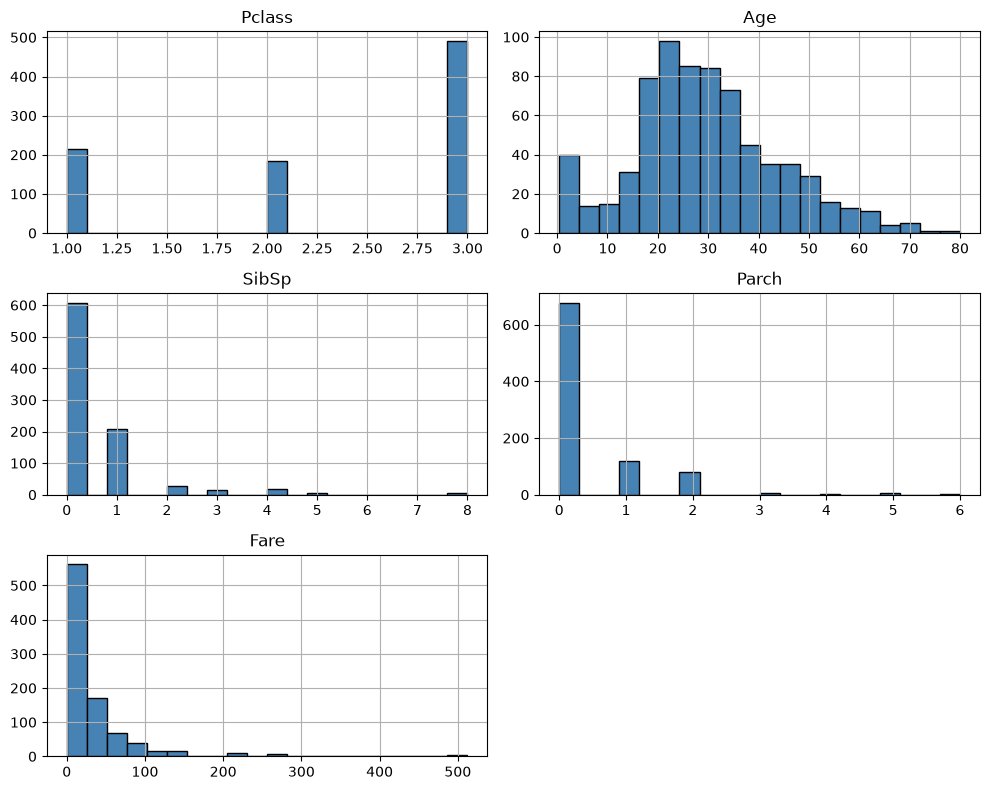

In [110]:
def plot_numeric_distributions(df, numeric_cols):
    df[numeric_cols].hist(figsize=(10, 8), bins=20, color='steelblue', edgecolor='black')
    plt.tight_layout()
    plt.show()

plot_numeric_distributions(df_raw, numeric_cols)


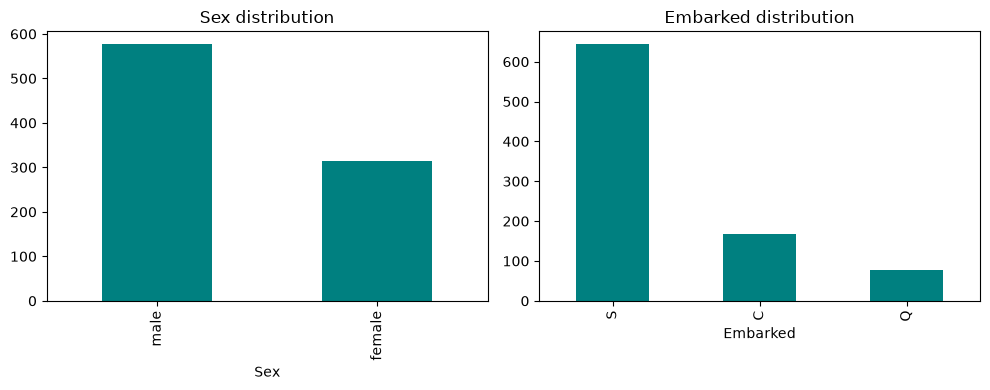

In [111]:
def plot_categorical_distributions(df, categorical_cols):
    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5*len(categorical_cols), 4))
    if len(categorical_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, categorical_cols):
        df[col].value_counts().plot(kind='bar', ax=ax, color='teal')
        ax.set_title(f'{col} distribution')
    plt.tight_layout()
    plt.show()

plot_categorical_distributions(df_raw, categorical_cols)

In [ ]:
te